In [3]:
!pip install mlflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 52.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.9/705.9 kB 19.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 11.2 MB/s eta 0:00:00


# test mlflow

In [2]:
import mlflow

In [4]:
mlflow.set_tracking_uri('http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/')

with mlflow.start_run():
    mlflow.log_param("param1",13)
    mlflow.log_metric("metric1",0.95)

🏃 View run masked-gnu-375 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/0/runs/ece6f6deb7714d52ac8c0f36419370b2
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/0


## Processing data

In [5]:

#creating baseline model

import numpy as np
import pandas as pd

In [13]:

df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [14]:
df.dropna(inplace=True)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [17]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [18]:
# Ensure necessary NLTK data is downloaded
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
# Define the preprocessing function
def preprocess_comment(comment):
    # Convert to lowercase
    comment = comment.lower()

    # Remove trailing and leading whitespaces
    comment = comment.strip()

    # Remove newline characters
    comment = re.sub(r'\n', ' ', comment)

    # Remove non-alphanumeric characters, except punctuation
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', '', comment)

    # Remove stopwords but retain important ones for sentiment analysis
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [20]:
# Apply the preprocessing function to the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [13]:

df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [21]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Step 1: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)  # Bag of Words model with a limit of 1000 features

In [16]:
X = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category']  # Assuming 'sentiment' is the target variable (0 or 1 for binary classification)

In [20]:
X[1].shape

(10000,)

In [21]:
y

0        1
1        1
2       -1
3        0
4        1
        ..
37244    0
37245    1
37246    0
37247    1
37248    0
Name: category, Length: 37028, dtype: int64

In [23]:
# Step 2: Set up the MLflow tracking server
mlflow.set_tracking_uri("http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/")

In [24]:
# Set or create an experiment
mlflow.set_experiment("RF Baseline")

2025/09/04 07:32:55 INFO mlflow.tracking.fluent: Experiment with name 'RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-925/426644671669676911', creation_time=1756971175015, experiment_id='426644671669676911', last_update_time=1756971175015, lifecycle_stage='active', name='RF Baseline', tags={}>

In [4]:
!pip install boto3 -q

In [26]:
import boto3

In [5]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 66.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 23.4 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: botocore
    Found existing installation: botocore 1.39.1
    Uninstalling botocore-1.39.1:
      Successfully uninstalled botocore-1.39.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
boto3 

In [29]:
!aws configure

AWS Access Key ID [None]: ^C



In [ ]:
import os

os.environ["AWS_ACCESS_KEY_ID"] = ""
os.environ["AWS_SECRET_ACCESS_KEY"] = ""
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"  # thay region bạn dùng

In [31]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

2025/09/04 07:48:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 07:48:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run RandomForest_Baseline_TrainTestSplit at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/426644671669676911/runs/5488ff42317742c0b5a1c5b750ce1b48
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/426644671669676911
Accuracy: 0.6512287334593573


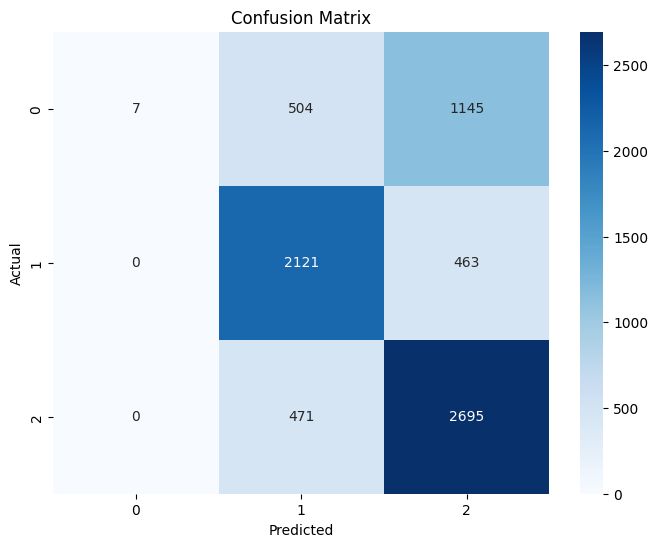

In [32]:
# Step 2: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("/kaggle/working/confusion_matrix.png")
    mlflow.log_artifact("/kaggle/working/confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("/kaggle/working/dataset.csv", index=False)
    mlflow.log_artifact("/kaggle/working/dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [ ]:
print(classification_report(y_test, y_pred))

# 3

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [8]:
import mlflow

In [9]:
mlflow.set_tracking_uri('http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/')

In [10]:
# Set or create an experiment
mlflow.set_experiment("Exp 2 - BoW vs TfIdf")

2025/09/04 08:53:15 INFO mlflow.tracking.fluent: Experiment with name 'Exp 2 - BoW vs TfIdf' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-925/313846788168838665', creation_time=1756975995610, experiment_id='313846788168838665', last_update_time=1756975995610, lifecycle_stage='active', name='Exp 2 - BoW vs TfIdf', tags={}>

In [22]:
df.to_csv("/kaggle/working/dataset.csv", index=False)

In [24]:
df = pd.read_csv('/kaggle/working/dataset.csv').dropna(subset=['clean_comment'])
df.shape

(36662, 2)

In [27]:
# Step 1: Function to run the experiment
def run_experiment(vectorizer_type, ngram_range, vectorizer_max_features, vectorizer_name):
    # Step 2: Vectorization
    if vectorizer_type == "BoW":
        vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)
    else:
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)

    X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)

    # Step 4: Define and train a Random Forest model
    with mlflow.start_run() as run:
        # Set tags for the experiment and run
        mlflow.set_tag("mlflow.runName", f"{vectorizer_name}_{ngram_range}_RandomForest")
        mlflow.set_tag("experiment_type", "feature_engineering")
        mlflow.set_tag("model_type", "RandomForestClassifier")

        # Add a description
        mlflow.set_tag("description", f"RandomForest with {vectorizer_name}, ngram_range={ngram_range}, max_features={vectorizer_max_features}")

        # Log vectorizer parameters
        mlflow.log_param("vectorizer_type", vectorizer_type)
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("vectorizer_max_features", vectorizer_max_features)

        # Log Random Forest parameters
        n_estimators = 200
        max_depth = 15

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)

        # Initialize and train the model
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Step 5: Make predictions and log metrics
        y_pred = model.predict(X_test)

        # Log accuracy
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric("accuracy", accuracy)

        # Log classification report
        classification_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # Log confusion matrix
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix: {vectorizer_name}, {ngram_range}")
        plt.savefig("/kaggle/working/confusion_matrix.png")
        mlflow.log_artifact("/kaggle/working/confusion_matrix.png")
        plt.close()

        # Log the model
        mlflow.sklearn.log_model(model, f"random_forest_model_{vectorizer_name}_{ngram_range}")

# Step 6: Run experiments for BoW and TF-IDF with different n-grams
ngram_ranges = [(1, 1), (1, 2), (1, 3)]  # unigrams, bigrams, trigrams
max_features = 5000  # Example max feature size

for ngram_range in ngram_ranges:
    # BoW Experiments
    run_experiment("BoW", ngram_range, max_features, vectorizer_name="BoW")

    # TF-IDF Experiments
    run_experiment("TF-IDF", ngram_range, max_features, vectorizer_name="TF-IDF")

2025/09/04 09:15:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 09:15:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run BoW_(1, 1)_RandomForest at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665/runs/9b3d1892e6a2476594458b6148d29a12
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665


2025/09/04 09:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 09:16:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TF-IDF_(1, 1)_RandomForest at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665/runs/fe26ce7a409a445b8eb717fbf3e9c5e3
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665


2025/09/04 09:17:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 09:17:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

🏃 View run TF-IDF_(1, 2)_RandomForest at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665/runs/ad0cb2eca13648a982c9fded9999db7b
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665


2025/09/04 09:18:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 09:19:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run BoW_(1, 3)_RandomForest at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665/runs/5ae9c0142b94448fbf9a5790a7bdb00a
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665


2025/09/04 09:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/04 09:20:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TF-IDF_(1, 3)_RandomForest at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665/runs/b3a53d05e200434f885356a7946a28ee
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/313846788168838665


# 4

In [28]:
df = pd.read_csv('/kaggle/working/dataset.csv').dropna(subset=['clean_comment'])
df.shape

(36662, 2)

In [29]:
import mlflow
# Step 2: Set up the MLflow tracking server
mlflow.set_tracking_uri('http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/')   

In [30]:
# Set or create an experiment
mlflow.set_experiment("Exp 3 - TfIdf Trigram max_features")

2025/09/04 09:40:31 INFO mlflow.tracking.fluent: Experiment with name 'Exp 3 - TfIdf Trigram max_features' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-925/368769037232256085', creation_time=1756978831982, experiment_id='368769037232256085', last_update_time=1756978831982, lifecycle_stage='active', name='Exp 3 - TfIdf Trigram max_features', tags={}>

In [31]:
# Step 1: Function to run the experiment
def run_experiment_tfidf_max_features(max_features):
    ngram_range = (1, 3)  # Trigram setting

    # Step 2: Vectorization using TF-IDF with varying max_features
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features)

    X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)

    # Step 4: Define and train a Random Forest model
    with mlflow.start_run() as run:
        # Set tags for the experiment and run
        mlflow.set_tag("mlflow.runName", f"TFIDF_Trigrams_max_features_{max_features}")
        mlflow.set_tag("experiment_type", "feature_engineering")
        mlflow.set_tag("model_type", "RandomForestClassifier")

        # Add a description
        mlflow.set_tag("description", f"RandomForest with TF-IDF Trigrams, max_features={max_features}")

        # Log vectorizer parameters
        mlflow.log_param("vectorizer_type", "TF-IDF")
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("vectorizer_max_features", max_features)

        # Log Random Forest parameters
        n_estimators = 200
        max_depth = 15

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)

        # Initialize and train the model
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Step 5: Make predictions and log metrics
        y_pred = model.predict(X_test)

        # Log accuracy
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric("accuracy", accuracy)

        # Log classification report
        classification_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # Log confusion matrix
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix: TF-IDF Trigrams, max_features={max_features}")
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")
        plt.close()

        # Log the model
        mlflow.sklearn.log_model(model,name=  f"random_forest_model_tfidf_trigrams_{max_features}")

# Step 6: Test various max_features values
max_features_values = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

for max_features in max_features_values:
    run_experiment_tfidf_max_features(max_features)

2025/09/04 09:41:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_Trigrams_max_features_1000 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085/runs/26e20371d2644cb7b39a4806b50e1c9b
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085


2025/09/04 09:42:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_Trigrams_max_features_2000 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085/runs/37e6ca3ddd474819b1f83e8d975c97e8
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085


2025/09/04 09:43:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

🏃 View run TFIDF_Trigrams_max_features_8000 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085/runs/11725a30a0714263a9443d1ed85a6018
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085


2025/09/04 09:48:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_Trigrams_max_features_9000 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085/runs/dd2fc4e409bf478dbc882e1506b5d208
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085


2025/09/04 09:49:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_Trigrams_max_features_10000 at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085/runs/c5ca184ea6954c83aa94288dd157be45
🧪 View experiment at: http://ec2-34-222-22-24.us-west-2.compute.amazonaws.com:5000/#/experiments/368769037232256085


# 5

In [32]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Load the dataset
dataset = pd.read_csv('/kaggle/working/dataset.csv')

# Drop rows with NaN values in 'clean_comment'
cleaned_dataset = dataset.dropna()

# Separate features and target
X_cleaned = cleaned_dataset['clean_comment']
y_cleaned = cleaned_dataset['category']

# Split the cleaned data into train and test sets (80-20 split)
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Apply TfidfVectorizer with trigram setting and max_features=10000
tfidf_cleaned = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)

# Fit the vectorizer on the training data and transform both train and test sets
X_train_tfidf_cleaned = tfidf_cleaned.fit_transform(X_train_cleaned)
X_test_tfidf_cleaned = tfidf_cleaned.transform(X_test_cleaned)

# Base learners
lightgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric="multi_logloss",
    is_unbalance=True,
    class_weight="balanced",
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1,  # L2 regularization,
    learning_rate=0.08081298097796712,
    n_estimators=367,
    max_depth=20
)

logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs', multi_class='multinomial')

# Meta-learner
knn_meta_learner = KNeighborsClassifier(n_neighbors=5)

# Create the StackingClassifier with LightGBM and LogisticRegression as base models, and KNN as meta-learner
stacking_model = StackingClassifier(
    estimators=[
        ('lightgbm', lightgbm_model),
        ('logistic_regression', logreg_model)
    ],
    final_estimator=knn_meta_learner,
    cv=5
)

# Train the stacking model
stacking_model.fit(X_train_tfidf_cleaned, y_train_cleaned)

# Make predictions on the test data
y_pred = stacking_model.predict(X_test_tfidf_cleaned)

# Generate classification report
print(classification_report(y_test_cleaned, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.508180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 131997
[LightGBM] [Info] Number of data points in the train set: 29329, number of used features: 4439
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further